# Employee Salary Increment Prediction
This notebook is intentionally left with empty code cells. Students must implement the solution.

## Step 1: Import Libraries
Explain required libraries like pandas, numpy, sklearn.

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

## Step 2: Load Dataset
Load the CSV file and display first few rows.

In [2]:
df = pd.read_csv('./data/Employee Salary Dataset.csv')
df

,EmployeeID,Name,Department,YearsExperience,CurrentSalary,PerformanceScore,IncrementPercentage,NewSalary
0,E0103,Ram,Unknown,17.0,45000.0,B,17.0,52650.0
1,E0436,Chris,Finance,1.0,100000.0,3,10.0,110000.0
2,E0271,NaN,Unknown,13.0,30000.0,A,-5.0,28500.0
3,E0107,Ram,Marketing,12.0,25000.0,A,15.0,28750.0
4,E0072,NaN,NaN,28.0,130000.0,NaN,NaN,130000.0
...,...,...,...,...,...,...,...,...
495,E0217,,Finance,21.0,25000.0,4,18.0,29500.0
496,E0301,John,Marketing,5.0,120000.0,2,15.0,138000.0
497,E0132,NaN,NaN,1.0,140000.0,1,11.0,155400.0
498,E0070,NaN,Unknown,22.0,115000.0,3,11.0,127650.0


## Step 3: Data Cleaning
Handle missing values, incorrect entries, and data types.

In [3]:
print("=" * 60)
print("BASIC INFO")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

BASIC INFO
Shape: (500, 8)

Data Types:
EmployeeID              object
Name                    object
Department              object
YearsExperience        float64
CurrentSalary          float64
PerformanceScore        object
IncrementPercentage    float64
NewSalary              float64
dtype: object

First 5 rows:


,EmployeeID,Name,Department,YearsExperience,CurrentSalary,PerformanceScore,IncrementPercentage,NewSalary
0,E0103,Ram,Unknown,17.0,45000.0,B,17.0,52650.0
1,E0436,Chris,Finance,1.0,100000.0,3,10.0,110000.0
2,E0271,NaN,Unknown,13.0,30000.0,A,-5.0,28500.0
3,E0107,Ram,Marketing,12.0,25000.0,A,15.0,28750.0
4,E0072,NaN,NaN,28.0,130000.0,NaN,NaN,130000.0


In [4]:
print("=" * 45)
print("MISSING VALUES")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

MISSING VALUES
                     Missing Count  Missing %
EmployeeID                       0        0.0
Name                            95       19.0
Department                      63       12.6
YearsExperience                 17        3.4
CurrentSalary                   10        2.0
PerformanceScore                67       13.4
IncrementPercentage             20        4.0
NewSalary                       10        2.0


In [5]:
# Step 1: Normalize invalid name entries to NaN
df['Name'] = df['Name'].str.strip()
df['Name'] = df['Name'].replace({'': np.nan, 'N/A': np.nan})

print(f"Total missing names after normalization: {df['Name'].isnull().sum()}")
# Should now show 154 (95 original + 59 invalid strings)

# Step 2: NOW fill all missing names with "Unknown"
df['Name'] = df['Name'].fillna('Unknown')

print(f"\nFinal name value counts:")
print(df['Name'].value_counts(dropna=False))

Total missing names after normalization: 154

Final name value counts:
Name
Unknown    154
John        68
Chris       64
Ram         59
Alex        59
Jane        49
Sita        47
Name: count, dtype: int64


In [6]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
df.isnull().sum()

EmployeeID              0
Name                    0
Department              0
YearsExperience        17
CurrentSalary          10
PerformanceScore       67
IncrementPercentage    20
NewSalary              10
dtype: int64

In [7]:
df['YearsExperience'] = df['YearsExperience'].fillna(df['YearsExperience'].median())
df.isnull().sum()

EmployeeID              0
Name                    0
Department              0
YearsExperience         0
CurrentSalary          10
PerformanceScore       67
IncrementPercentage    20
NewSalary              10
dtype: int64

In [8]:
df['CurrentSalary'] = df.groupby('Department')['CurrentSalary'].transform(
    lambda x: x.fillna(x.median())
)
df.isnull().sum()

EmployeeID              0
Name                    0
Department              0
YearsExperience         0
CurrentSalary           0
PerformanceScore       67
IncrementPercentage    20
NewSalary              10
dtype: int64

In [9]:
df['PerformanceScore'] = df['PerformanceScore'].fillna(df['PerformanceScore'].mode()[0])
df.isnull().sum()

EmployeeID              0
Name                    0
Department              0
YearsExperience         0
CurrentSalary           0
PerformanceScore        0
IncrementPercentage    20
NewSalary              10
dtype: int64

In [10]:
df['IncrementPercentage'] = df['IncrementPercentage'].fillna(df['IncrementPercentage'].median())
df.isnull().sum()

EmployeeID              0
Name                    0
Department              0
YearsExperience         0
CurrentSalary           0
PerformanceScore        0
IncrementPercentage     0
NewSalary              10
dtype: int64

In [11]:
# Salary: negative values are invalid → NaN
df.loc[df['CurrentSalary'] < 0, 'CurrentSalary'] = np.nan

# YearsExperience: negative and impossibly high → NaN
df.loc[df['YearsExperience'] < 0, 'YearsExperience'] = np.nan
df.loc[df['YearsExperience'] > 50, 'YearsExperience'] = np.nan

# --- Step 2: NOW impute missing values ---

df['Name'] = df['Name'].fillna('Unknown')
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

df['YearsExperience'] = df['YearsExperience'].fillna(
    df['YearsExperience'].median()
)

# Group-wise median for salary (now clean!)
df['CurrentSalary'] = df.groupby('Department')['CurrentSalary'].transform(
    lambda x: x.fillna(x.median())
)

df['IncrementPercentage'] = df['IncrementPercentage'].fillna(
    df['IncrementPercentage'].median()
)

# --- Step 3: Recalculate derived column ---
df['NewSalary'] = df['CurrentSalary'] * (1 + df['IncrementPercentage'] / 100)

# --- Verify ---
print("Missing values:")
print(df.isnull().sum())
print(f"\nMin salary: {df['CurrentSalary'].min()}")  # should be positive now
print(f"Min experience: {df['YearsExperience'].min()}")  # should be ≥ 0

Missing values:
EmployeeID             0
Name                   0
Department             0
YearsExperience        0
CurrentSalary          0
PerformanceScore       0
IncrementPercentage    0
NewSalary              0
dtype: int64

Min salary: 20000.0
Min experience: 0.0


In [12]:
print("\n" + "=" * 60)
print("DUPLICATE EMPLOYEE IDs")
print("=" * 60)
 
dup_ids = df[df.duplicated('EmployeeID', keep=False)]
print(f"Total rows with duplicate IDs: {len(dup_ids)}")
print(f"Number of duplicate IDs: {df['EmployeeID'].duplicated().sum()}")
print(f"\nSample duplicates:")
print(dup_ids.head(10))


DUPLICATE EMPLOYEE IDs
Total rows with duplicate IDs: 295
Number of duplicate IDs: 171

Sample duplicates:
   EmployeeID     Name Department  YearsExperience  CurrentSalary  \
0       E0103      Ram    Unknown             17.0        45000.0   
2       E0271  Unknown    Unknown             13.0        30000.0   
5       E0021      Ram         HR             11.0       115000.0   
8       E0215  Unknown    Finance             12.0        75000.0   
9       E0331  Unknown    Finance             26.0       145000.0   
12      E0373      Ram    Unknown             14.0        80000.0   
13      E0100  Unknown         IT             23.0        90000.0   
14      E0131     John    Finance              5.0       140000.0   
16      E0344  Unknown  Marketing             29.0        95000.0   
17      E0492     John    Finance              6.0        65000.0   

   PerformanceScore  IncrementPercentage  NewSalary  
0                 B                 17.0    52650.0  
2                 A     

In [13]:
# Step 1: Remove any TRUE full-row duplicates first
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} true duplicate rows")

Removed 0 true duplicate rows


In [14]:
# Step 2: Reassign unique IDs to fix the ID conflicts
df = df.reset_index(drop=True)
df['EmployeeID'] = ['E' + str(i+1).zfill(4) for i in range(len(df))]

In [15]:
# Verify
print(f"Unique IDs now: {df['EmployeeID'].nunique()} out of {len(df)} rows")

Unique IDs now: 500 out of 500 rows


In [16]:
print("\n" + "=" * 60)
print("DUPLICATE EMPLOYEE IDs")
print("=" * 60)
 
dup_ids = df[df.duplicated('EmployeeID', keep=False)]
print(f"Total rows with duplicate IDs: {len(dup_ids)}")
print(f"Number of duplicate IDs: {df['EmployeeID'].duplicated().sum()}")
print(f"\nSample duplicates:")
print(dup_ids.head(10))


DUPLICATE EMPLOYEE IDs
Total rows with duplicate IDs: 0
Number of duplicate IDs: 0

Sample duplicates:
Empty DataFrame
Columns: [EmployeeID, Name, Department, YearsExperience, CurrentSalary, PerformanceScore, IncrementPercentage, NewSalary]
Index: []


In [17]:
df.head()

,EmployeeID,Name,Department,YearsExperience,CurrentSalary,PerformanceScore,IncrementPercentage,NewSalary
0,E0001,Ram,Unknown,17.0,45000.0,B,17.0,52650.0
1,E0002,Chris,Finance,1.0,100000.0,3,10.0,110000.0
2,E0003,Unknown,Unknown,13.0,30000.0,A,-5.0,28500.0
3,E0004,Ram,Marketing,12.0,25000.0,A,15.0,28750.0
4,E0005,Unknown,Marketing,28.0,130000.0,4,11.0,144300.0


In [18]:
print(df['Department'].value_counts(dropna=False))

Department
Marketing    146
Finance       79
IT            79
HR            74
Unknown       67
Sales         55
Name: count, dtype: int64


In [19]:
print("\n" + "=" * 60)
print("INCREMENT PERCENTAGE - RANGE CHECK")
print("=" * 60)
 
print(f"Min: {df['IncrementPercentage'].min()}")
print(f"Max: {df['IncrementPercentage'].max()}")
print(f"Mean: {df['IncrementPercentage'].mean():.2f}")
 
outlier_inc = df[(df['IncrementPercentage'] < 0) | (df['IncrementPercentage'] > 30)]
print(f"\nSuspicious values (< 0 or > 30%): {len(outlier_inc)} rows")
print(outlier_inc[['EmployeeID', 'Name', 'IncrementPercentage']])


INCREMENT PERCENTAGE - RANGE CHECK
Min: -5.0
Max: 50.0
Mean: 11.28

Suspicious values (< 0 or > 30%): 41 rows
    EmployeeID     Name  IncrementPercentage
2        E0003  Unknown                 -5.0
18       E0019    Chris                 50.0
26       E0027      Ram                 -5.0
27       E0028      Ram                 -5.0
52       E0053     John                 -5.0
54       E0055     John                 50.0
67       E0068  Unknown                 50.0
70       E0071    Chris                 -5.0
85       E0086    Chris                 -5.0
90       E0091      Ram                 50.0
98       E0099     Alex                 50.0
115      E0116    Chris                 50.0
116      E0117     Alex                 -5.0
141      E0142     Alex                 50.0
145      E0146     John                 -5.0
165      E0166      Ram                 -5.0
175      E0176     John                 50.0
177      E0178  Unknown                 -5.0
181      E0182  Unknown           

## Step 4: Exploratory Data Analysis
Visualize distributions and relationships.

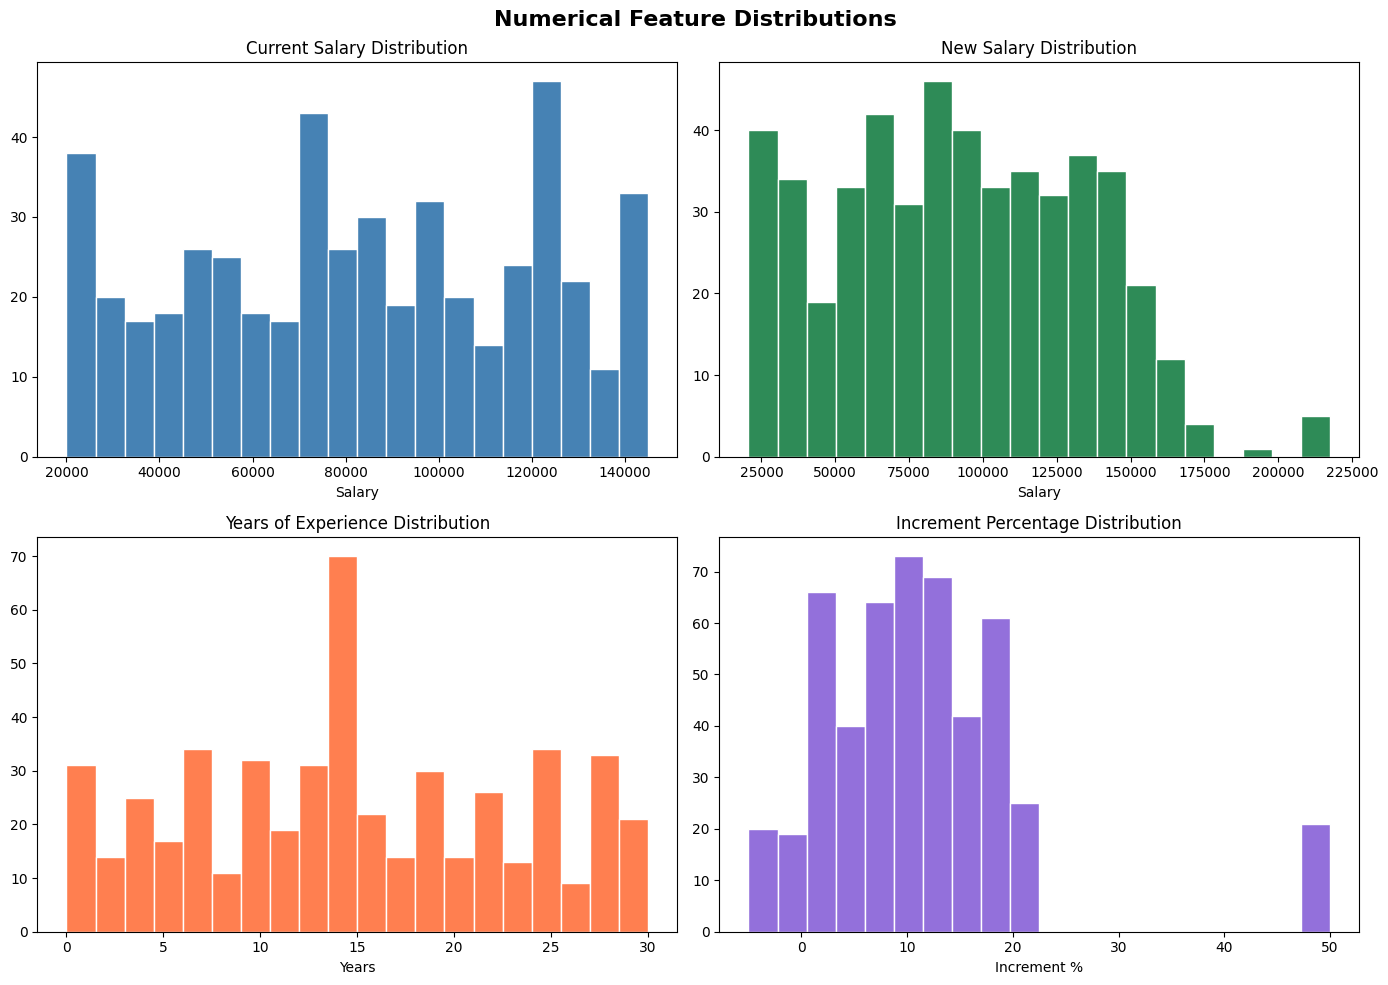

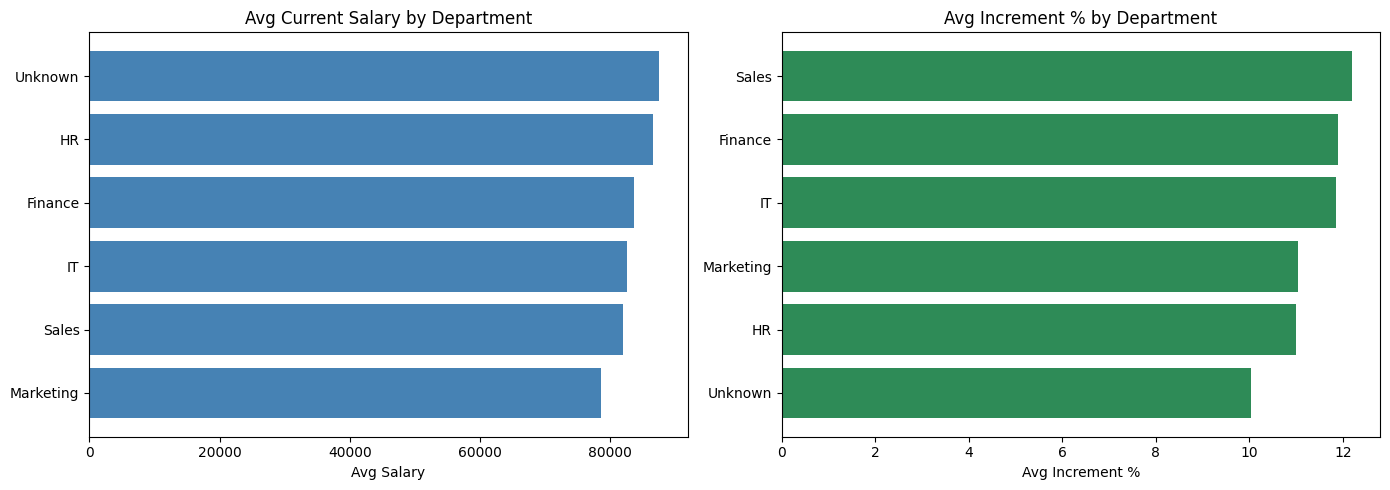

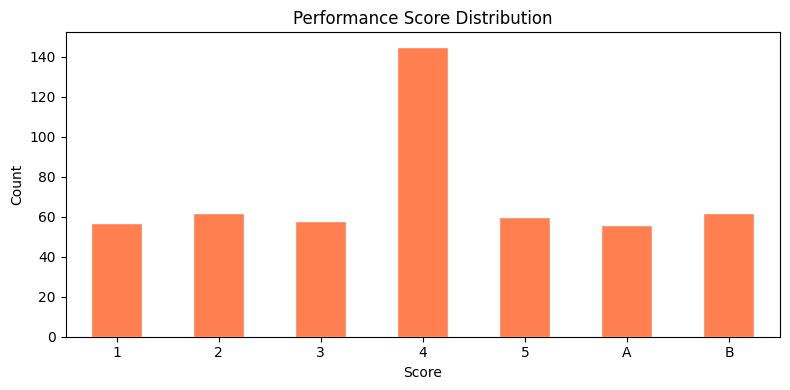

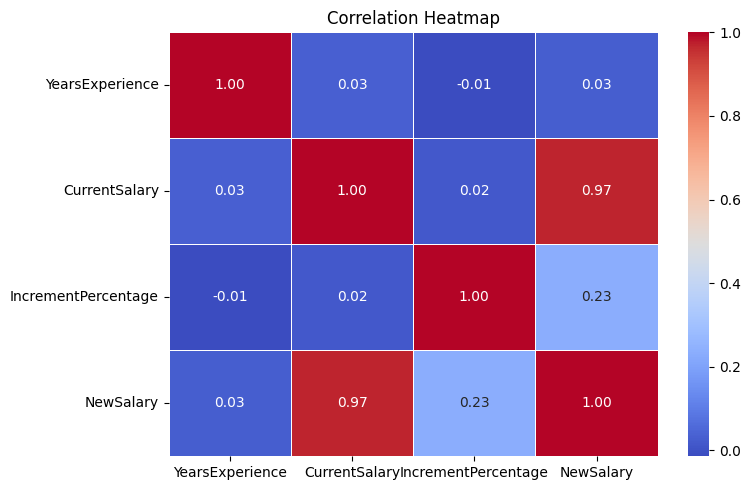

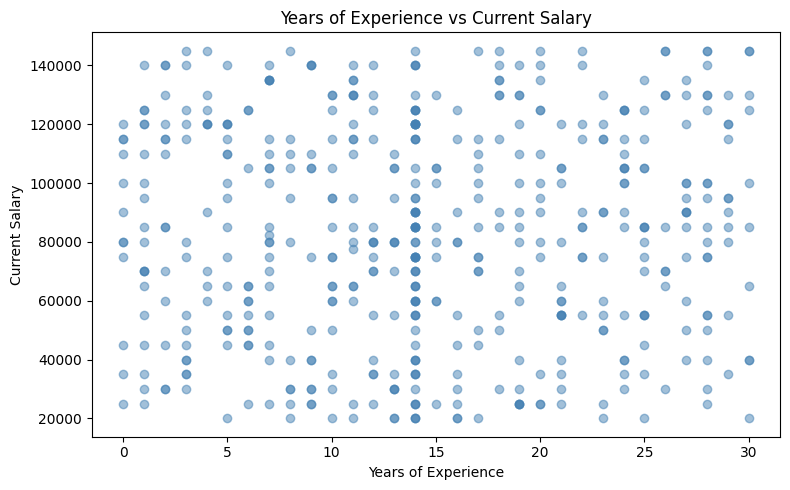

In [20]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Numerical Feature Distributions", fontsize=16, fontweight='bold')

axes[0, 0].hist(df['CurrentSalary'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Current Salary Distribution")
axes[0, 0].set_xlabel("Salary")

axes[0, 1].hist(df['NewSalary'], bins=20, color='seagreen', edgecolor='white')
axes[0, 1].set_title("New Salary Distribution")
axes[0, 1].set_xlabel("Salary")

axes[1, 0].hist(df['YearsExperience'], bins=20, color='coral', edgecolor='white')
axes[1, 0].set_title("Years of Experience Distribution")
axes[1, 0].set_xlabel("Years")

axes[1, 1].hist(df['IncrementPercentage'], bins=20, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title("Increment Percentage Distribution")
axes[1, 1].set_xlabel("Increment %")

plt.tight_layout()
plt.show()

# Department-wise analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_salary = df.groupby('Department')['CurrentSalary'].mean().sort_values()
axes[0].barh(dept_salary.index, dept_salary.values, color='steelblue')
axes[0].set_title("Avg Current Salary by Department")
axes[0].set_xlabel("Avg Salary")

dept_inc = df.groupby('Department')['IncrementPercentage'].mean().sort_values()
axes[1].barh(dept_inc.index, dept_inc.values, color='seagreen')
axes[1].set_title("Avg Increment % by Department")
axes[1].set_xlabel("Avg Increment %")

plt.tight_layout()
plt.show()

# PerformanceScore distribution
plt.figure(figsize=(8, 4))
ps_counts = df['PerformanceScore'].value_counts().sort_index()
ps_counts.plot(kind='bar', color='coral', edgecolor='white')
plt.title("Performance Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(8, 5))
numeric_cols = df[['YearsExperience', 'CurrentSalary', 'IncrementPercentage', 'NewSalary']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Salary vs Experience scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['CurrentSalary'], alpha=0.5, color='steelblue')
plt.title("Years of Experience vs Current Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Current Salary")
plt.tight_layout()
plt.show()


## Step 5: Feature Encoding
Convert categorical variables into numeric form.

In [21]:
# --- Normalize PerformanceScore (mix of letters A,B and numbers 1-4) ---
# Treat A as top grade (5) and B as second (4); numeric scores map directly
perf_map = {'1': 1, '2': 2, '3': 3, '4': 4, 'B': 4, 'A': 5}
df['PerformanceScore'] = df['PerformanceScore'].astype(str).str.strip().map(perf_map)
print("PerformanceScore value counts after normalization:")
print(df['PerformanceScore'].value_counts().sort_index())

# --- Encode Department with LabelEncoder ---
le_dept = LabelEncoder()
df['Department_enc'] = le_dept.fit_transform(df['Department'])
print("\nDepartment encoding:")
for label, code in zip(le_dept.classes_, le_dept.transform(le_dept.classes_)):
    print(f"  {label} → {code}")

# --- Create target variable: IncrementCategory ---
# Bin IncrementPercentage into Low / Medium / High
bins   = [-np.inf, 5, 15, np.inf]
labels = ['Low', 'Medium', 'High']
df['IncrementCategory'] = pd.cut(df['IncrementPercentage'], bins=bins, labels=labels)
print("\nIncrementCategory distribution:")
print(df['IncrementCategory'].value_counts())

# --- Select features and target ---
features = ['YearsExperience', 'CurrentSalary', 'PerformanceScore', 'Department_enc']
target   = 'IncrementCategory'

X = df[features]
y = df[target]

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target series shape  : {y.shape}")
print(f"\nFeature preview:")
print(X.head())


PerformanceScore value counts after normalization:
PerformanceScore
1.0     57
2.0     62
3.0     58
4.0    207
5.0     56
Name: count, dtype: int64

Department encoding:
  Finance → 0
  HR → 1
  IT → 2
  Marketing → 3
  Sales → 4
  Unknown → 5

IncrementCategory distribution:
IncrementCategory
Medium    219
Low       145
High      136
Name: count, dtype: int64

Feature matrix shape : (500, 4)
Target series shape  : (500,)

Feature preview:
   YearsExperience  CurrentSalary  PerformanceScore  Department_enc
0             17.0        45000.0               4.0               5
1              1.0       100000.0               3.0               0
2             13.0        30000.0               5.0               5
3             12.0        25000.0               5.0               3
4             28.0       130000.0               4.0               3


## Step 6: Train-Test Split
Split dataset into training and testing sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute any remaining NaN values in features
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# Scale features (important for distance/margin-based models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())


Training set   : 400 samples
Test set       : 100 samples

Class distribution in training set:
IncrementCategory
Medium    175
Low       116
High      109
Name: count, dtype: int64

Class distribution in test set:
IncrementCategory
Medium    44
Low       29
High      27
Name: count, dtype: int64


## Step 7: Logistic Regression Model
Train and evaluate Logistic Regression.

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")


Logistic Regression Accuracy: 0.4300 (43.00%)


## Step 8: Naive Bayes Model
Train and evaluate Naive Bayes.

In [24]:
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {acc_nb:.4f} ({acc_nb*100:.2f}%)")


Naive Bayes Accuracy: 0.4400 (44.00%)


## Step 9: Decision Tree Model
Train and evaluate Decision Tree.

In [25]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)          # Decision trees don't need scaling
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)")


Decision Tree Accuracy: 0.4100 (41.00%)


## Step 10: Support Vector Machine (SVM)
Train and evaluate SVM.

In [26]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {acc_svm:.4f} ({acc_svm*100:.2f}%)")


SVM Accuracy: 0.4000 (40.00%)


## Step 11: K-Nearest Neighbors (KNN)
Train and evaluate KNN.

In [27]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN (k=7) Accuracy: {acc_knn:.4f} ({acc_knn*100:.2f}%)")


KNN (k=7) Accuracy: 0.3000 (30.00%)


## Step 12: Model Comparison
Compare accuracy of all models.

Model                    Accuracy        %
Naive Bayes                0.4400   44.00%
Logistic Regression        0.4300   43.00%
Decision Tree              0.4100   41.00%
SVM                        0.4000   40.00%
KNN                        0.3000   30.00%

Best Model: Naive Bayes  (44.00%)


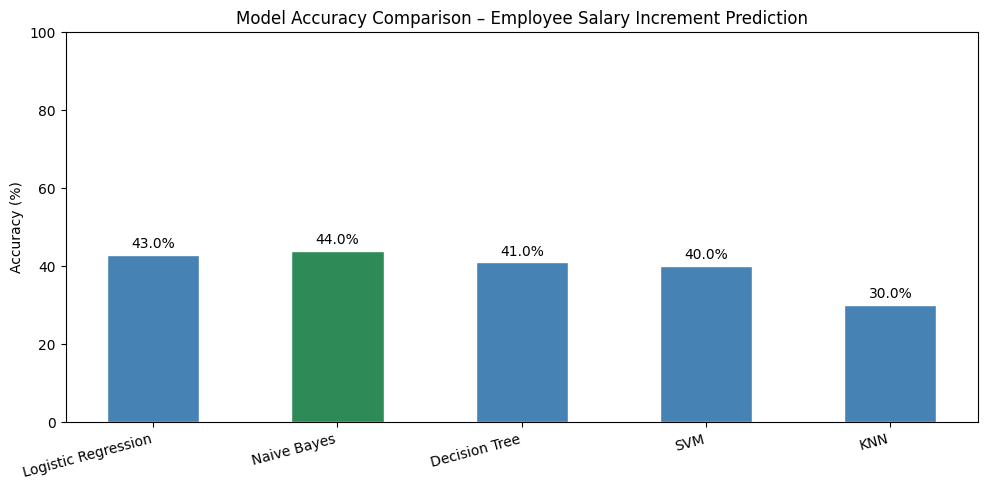

In [28]:
results = {
    'Logistic Regression': acc_lr,
    'Naive Bayes':         acc_nb,
    'Decision Tree':       acc_dt,
    'SVM':                 acc_svm,
    'KNN':                 acc_knn,
}

print("=" * 45)
print(f"{'Model':<22} {'Accuracy':>10} {'%':>8}")
print("=" * 45)
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<22} {acc:>10.4f} {acc*100:>7.2f}%")
print("=" * 45)

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model}  ({results[best_model]*100:.2f}%)")

# Bar chart comparison
plt.figure(figsize=(10, 5))
colors = ['steelblue' if m != best_model else 'seagreen' for m in results.keys()]
bars = plt.bar(results.keys(), [v * 100 for v in results.values()], color=colors, edgecolor='white', width=0.5)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison – Employee Salary Increment Prediction")
plt.ylim(0, 100)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val*100:.1f}%", ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()
